In [56]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.linear_model import LinearRegression

In [49]:
train_dataset = torchvision.datasets.MNIST(root="data/", train=True, download=True)
test_dataset = torchvision.datasets.MNIST(root="data/", train=False, download=True)

X_train = train_dataset.data.numpy().astype(np.float32).reshape(len(train_dataset), -1) / 255.0
y_train = np.eye(10)[train_dataset.targets.numpy().astype(np.int32)]

X_test = test_dataset.data.numpy().astype(np.float32).reshape(len(test_dataset), -1) / 255.0
y_test = np.eye(10)[test_dataset.targets.numpy().astype(np.int32)]

In [50]:
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp = np.exp(x)
    return exp / np.sum(exp, axis=1, keepdims=True)

In [51]:
class Layer():
    def __init__(self, shape, activation=True):
        self.weights =  np.random.randn(*shape) * np.sqrt(2 / shape[0])
        self.biases = np.zeros((1,shape[1]))
        self.activation = activation

    def print(self):
        print(self.weights)
        print()
        print(self.biases)
        
    def forward(self, X):
        self.input = X
        self.z = np.dot(self.input, self.weights) + self.biases
        self.a = relu(self.z) if self.activation else self.z
        return self.a
    
    def updateParams(self, dw, db, lr):
        self.weights -= dw * lr
        self.biases -= db * lr
    
    def backward(self, gradOut, learningRate):
        da = (self.z > 0) if self.activation else 1
        dz = gradOut * da

        dw = np.dot(self.input.T, dz) / dz.shape[0]
        db = np.sum(dz, axis=0, keepdims=True) / dz.shape[0]

        self.updateParams(dw, db, learningRate)

        gradInput = np.dot(dz, self.weights.T)
        return gradInput

In [96]:
class Network():
    def __init__(self, layerSizes):
        self.layers = []
        for i in range(len(layerSizes)-1):
            activation = i != len(layerSizes)-2
            self.layers.append(Layer((layerSizes[i], layerSizes[i+1]), activation))
            
        self.learningRate = []
        self.epochs = []
        self.batchSize = []
        self.accuracyArray = []
        self.lossesArray = []
        
    def printparams(self):
        """prints all network info"""
        for i, layer in enumerate(self.layers):
            print(f"\n Layer {i+1}:")
            print(f"Weights: {layer.weights[0][:5]}...")
            print(f"Biases: {layer.biases[0][:5]}...")
            
    def save(self, filename):
        model_data = {}
        for i, layer in enumerate(self.layers):
            model_data[f"w{i}"] = layer.weights
            model_data[f"b{i}"] = layer.biases
        model_data[f"lr"] = self.learningRate
        model_data[f"bs"] = self.batchSize
        model_data[f"a"] = self.accuracyArray
        model_data[f"l"] = self.lossesArray
        np.savez(filename, **model_data)
        print(f"Model saved to {filename}")

    def load(self, filename):
        model_data = np.load(filename, allow_pickle=True)
        for i, layer in enumerate(self.layers):
            layer.weights = model_data[f"w{i}"]
            layer.biases = model_data[f"b{i}"]
        self.learningRate = model_data[f"lr"]
        self.batchSize = model_data[f"bs"]
        self.accuracyArray = model_data[f"a"]
        self.lossesArray = model_data[f"l"]
        print(f"Model loaded from {filename}")
    
    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return softmax(X)
    
    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)
    
    def train(self, X, Y, X_test, Y_test, learningRate, epochs, batchSize):        
        self.learningRate.append(learningRate)
        self.epochs.append(epochs)
        self.batchSize.append(batchSize)
        
        losses = []
        accuracies = []
        n = len(X)
        for epoch in range(epochs):
            totalLoss = 0
            indices = np.random.permutation(n)
            for i in range(0, n, batchSize):
                batchIdx = indices[i:i+batchSize]
                x = X[batchIdx]
                y = Y[batchIdx]
                
                y_hat = self.forward(x)
                grad = y_hat - y
                
                for layer in reversed(self.layers):
                    grad = layer.backward(grad, learningRate)
                
                totalLoss += - np.sum(y * np.log(y_hat + 1e-12))
        
            loss = totalLoss / n
            preds = np.argmax(self.forward(X_test), axis=1)
            true = np.argmax(Y_test, axis=1)
            accuracy = np.mean(preds == true)

            losses.append(loss)
            accuracies.append(accuracy)
            
            if (epoch+1) % 1 == 0:
                print(f"Epoch {epoch+1}: Loss={loss:.4f}  Test Accuracy={accuracy:.4f}")
            
        self.accuracyArray.append(accuracies)
        self.lossesArray.append(losses)

In [ ]:
model = Network((784, 512, 256, 128, 10))
#for push

In [ ]:
#model.train(X_train, y_train, X_test, y_test, learningRate=0.001, epochs=100, batchSize=64)
#model.train(X_train, y_train, X_test, y_test, learningRate=0.0005, epochs=100, batchSize=128)
model.train(X_train, y_train, X_test, y_test, learningRate=0.0001, epochs=100, batchSize=256)

Epoch 1: Loss=0.0850  Test Accuracy=0.9680
Epoch 2: Loss=0.0847  Test Accuracy=0.9681
Epoch 3: Loss=0.0845  Test Accuracy=0.9682
Epoch 4: Loss=0.0844  Test Accuracy=0.9680
Epoch 5: Loss=0.0842  Test Accuracy=0.9682
Epoch 6: Loss=0.0840  Test Accuracy=0.9677
Epoch 7: Loss=0.0838  Test Accuracy=0.9683
Epoch 8: Loss=0.0836  Test Accuracy=0.9681
Epoch 9: Loss=0.0834  Test Accuracy=0.9681
Epoch 10: Loss=0.0832  Test Accuracy=0.9682
Epoch 11: Loss=0.0830  Test Accuracy=0.9682
Epoch 12: Loss=0.0828  Test Accuracy=0.9681
Epoch 13: Loss=0.0827  Test Accuracy=0.9683
Epoch 14: Loss=0.0825  Test Accuracy=0.9682
Epoch 15: Loss=0.0823  Test Accuracy=0.9683
Epoch 16: Loss=0.0821  Test Accuracy=0.9683
Epoch 17: Loss=0.0820  Test Accuracy=0.9684
Epoch 18: Loss=0.0818  Test Accuracy=0.9683
Epoch 19: Loss=0.0816  Test Accuracy=0.9683
Epoch 20: Loss=0.0814  Test Accuracy=0.9686
Epoch 21: Loss=0.0813  Test Accuracy=0.9686
Epoch 22: Loss=0.0811  Test Accuracy=0.9686
Epoch 23: Loss=0.0809  Test Accuracy=0.96

In [104]:
model.save(f"models/1")
print(f"Maximum accuracy reached by the model on most recent training loop: {np.max(model.accuracyArray[-1])}")
print(f"Minimum loss reached by the model on most recent training loop: {np.min(model.lossesArray[-1])}")
print("On the same iteration") if np.argmax(model.accuracyArray[-1])==np.argmin(model.lossesArray[-1]) else print("On different uterations")

Model saved to models/1
Maximum accuracy reached by the model on most recent training loop: 0.9713
Minimum loss reached by the model on most recent training loop: 0.06897820393192329
On different uterations


AttributeError: 'Network' object has no attribute 'lossesArray'

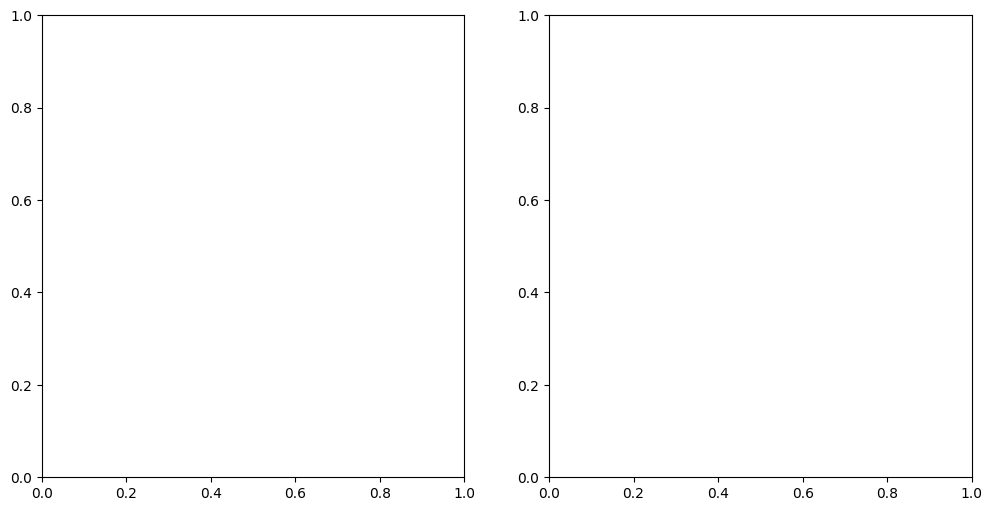

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

losses = model.lossesArray.reshape(1,-1)
accuracy = model.accuracyArray.reshape(1,-1)
n = len(accuracy)

ax[0].plot(losses, color='red', linestyle='-', label='Model Loss')
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Average Loss")
ax[0].legend()

fitRange = np.linspace(0, n, n).reshape(-1,1)
fitVals = accuracy
fit = LinearRegression().fit(fitRange, fitVals)
plotRange = np.linspace(0, n, n).reshape(-1,1)
plotVals = fit.predict(plotRange)

ax[1].plot(accuracy, color='blue', linestyle='-', label='Model Accuracy')
ax[1].plot(plotRange, plotVals, color='red', linestyle='--', label='Linear Fit')
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Percentage Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

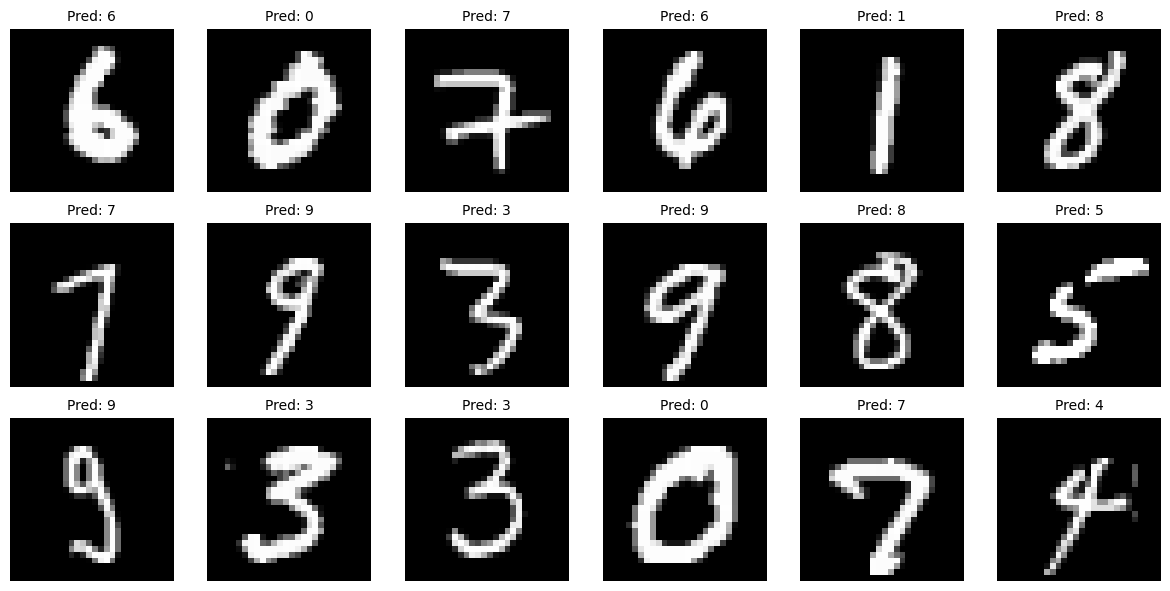

In [ ]:
offset = 2

fig, ax = plt.subplots(3, 6, figsize=(12,6))
for i in range(3):
    for j in range(6):
        idx = i*6 + j + offset*3*6
        img = train_dataset.data[idx].numpy()
        ax[i, j].imshow(img, cmap='gray')
        ax[i, j].axis('off')
        
        x = img.reshape(1, -1) / 255.0
        pred = model.predict(x)[0]
        ax[i, j].set_title(f"Pred: {pred}", fontsize=10)

plt.tight_layout()
plt.show()

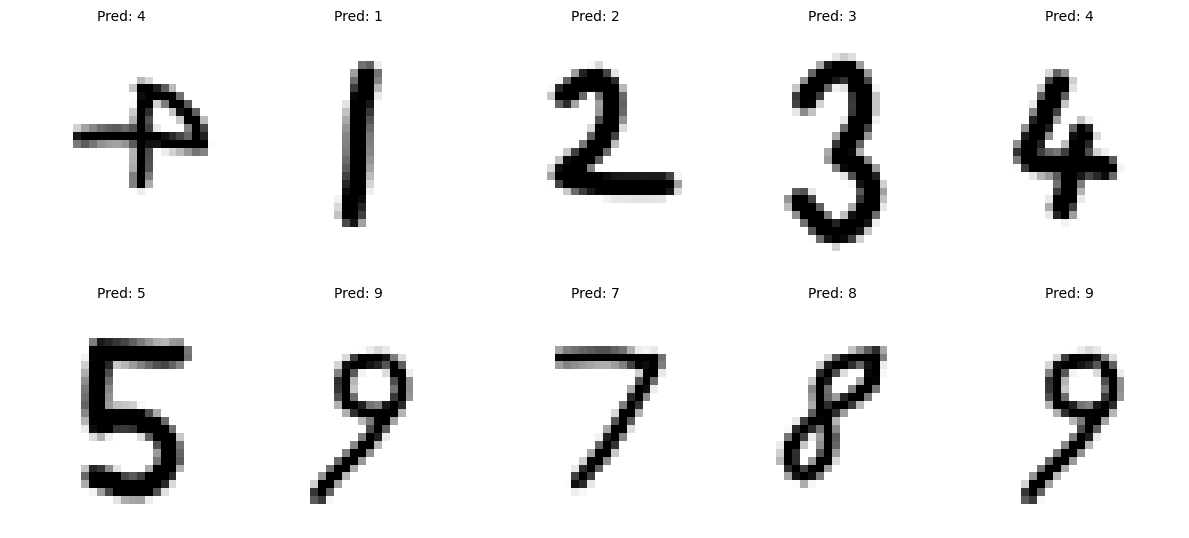

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(12,6))

for i in range(2):
    for j in range(5):
        idx = i*5 + j
        img = Image.open(f"testImages/{i*5+j}.png")
        ax[i, j].imshow(img, cmap='gray')
        ax[i, j].axis('off')
        
        x = 1-np.array(Image.open(f"testImages/{i*5+j}.png").convert("L")).reshape(1, 784) / 255.0
        pred = model.predict(x)[0]
        ax[i, j].set_title(f"Pred: {pred}", fontsize=10)

plt.tight_layout()
plt.show()